# General Mechanics Tests: Solar, Hydrogen, and Galactic Windows (SI-2019 Temporal Form)

**Author:** P. Reginald (ORCID: [0009-0007-8303-8627](https://orcid.org/0009-0007-8303-8627))

This public notebook reports three **General Mechanics (GM)** comparison windows written directly in **SI-2019 temporal form**:

- **Solar:** Mercury perihelion advance, solar-limb deflection, and solar surface redshift.
- **Hydrogen:** electron rest-energy rate and hydrogen shell radii.
- **Galactic:** an outer-rotation comparison between a Keplerian baseline, a GR-style SI-temporal correction, and GM 2D confinement scaling.

Only the public comparison layer is included here: the formulas, plots, tables, and short explanatory notes needed to read the tests.

### 1.0 Comparative Units and Hidden Temporal Dependency

Let a reported quantity be written as
$$
Q(t)=q(t)u(t),
$$
where $q(t)$ is the numerical value and $u(t)$ is the reporting unit. Then
$$
\frac{dQ}{dt}
=
u(t)\frac{dq}{dt}
+
q(t)\frac{du}{dt}.
$$

If $u(t)$ is treated as constant when it is not, the second term is dropped. That omission is the **chain-rule defect**.

This point is universal. Any **comparative unit with hidden temporal dependency** is unsafe as a primitive variable in calculus with respect to time.

In this notebook, the important practical cases are:
- distance handled as **causal duration**,
- mass handled through its **rest-energy rate [Hz]**.

Comparative units remain acceptable as reporting forms, but not as primitive variables when their temporal dependence remains implicit.

### 1.1 SI-2019 Temporal Form

This notebook is written directly in the **2019 SI defining-constant framework**. The second is the operational clock unit. The metre is treated through the fixed light speed $c$, so spatial length is handled as a causal light-travel duration. The kilogram is treated through the fixed Planck constant $h$ together with $c$ and the second, so mass enters the numerical layer through its rest-energy rate.

In the notation used here, **Kz** is the **Hz-rate label** attached to that SI-temporal rewrite. When a distinct **Kick** label is needed, it is written **Kk**. No auxiliary unit convention and no $h=1$ reduction are used anywhere in this public notebook.

Transport speeds are handled through the dimensionless ratio
$$\beta = \frac{v}{c}, \qquad 0 \le \beta \le 1.$$
When a transport speed is written as $1$, it means one light-speed unit in this normalised ratio.

The Hz-rate rewrite used throughout the notebook, written with the **Kz** label in GM notation, is
$$
E_{\mathrm{Kz}} = \frac{E}{h},\qquad
m_{\mathrm{Kz}} = \frac{m c^2}{h},\qquad
T_{\mathrm{Kz}} = \frac{k_B T}{h},\qquad
P_{\mathrm{Kz}} = \frac{P}{h}.
$$

In that sense, the notebook uses **only SI-2019 quantities** while expressing the length and mass sectors through their time-based defining relations.

### 1.2 SI-2019 Temporal Rewrite Used in the Calculations

For numerical comparisons, the catalog masses are rewritten as temporal rates:
$$f_{\rm Kz}(M) \equiv f_{\rm Hz}(M) = \frac{M c_{\rm SI}^2}{h_{\rm SI}}.$$

The Solar source scale is then evaluated as
$$\mu_{\rm num} = \kappa_{\rm vac}^{(\rm num)} f_{\rm Kz}(M),\qquad
  \kappa_{\rm vac}^{(\rm num)} = \frac{G_{\rm SI} h_{\rm SI}}{c_{\rm SI}^4}.$$

These expressions do not introduce a second unit system; they are the SI-2019 temporal form used in the public numerical layer below.

### 1.3 Small-Gradient Linearisation (Nonlinear → Linear)

In the Solar tests we work in a **small-gradient regime**
$$\epsilon(r) = \left|\frac{\mu}{r}\right| \ll 1,$$
so the nonlinear GM structures are truncated to leading-order terms in $\mu/r$. The macro expressions
$$\Delta\phi_{\rm GM} = \frac{6\pi\mu}{p}, \qquad
  \delta_{\rm GM}(b) = \frac{4\mu}{b}, \qquad
  z_{\rm GM}(R) = \frac{\mu}{R}$$
are the comparison formulas evaluated numerically below after assigning a value to $\mu$ through the SI-2019 temporal rewrite.



In [1]:
# 1. INPUTS (SI-2019 TEMPORAL LAYER)
# ==================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Exact defining constants used in the 2019 SI
c_SI = 299_792_458.0      # m/s
h_SI = 6.62607015e-34     # J s

# Measured constants (CODATA)
G_SI = 6.67430e-11        # m^3 kg^-1 s^-2
alpha_fs = 7.297352569e-3 # Fine structure constant

# Solar system ephemerides (catalog)
M_sun_kg = 1.98847e30
R_sun_m  = 695_700.0 * 1000.0
a_mer_m  = 57_909_050.0 * 1000.0
e_mer    = 0.205630
T_mer_s  = 87.9691 * 86400.0
century_s = 36525.0 * 86400.0   # seconds per Julian century

# Hydrogen parameters
m_e_kg = 9.10938356e-31
a0_ref = 5.291772109e-11        # Bohr radius (m, NIST)

# Angular conversion: radians -> arcseconds
ARCSEC = 3600.0 * 180.0 / math.pi

print("SI-2019 temporal environment initialised.")


Matplotlib is building the font cache; this may take a moment.


SI-2019 temporal environment initialised.


In [2]:
# 2. MASS-TO-RATE REWRITE AND NUMERICAL mu
# =========================================
# SI-2019 temporal form: transport speed is normalised by c,
# while energy-like quantities are represented as rates via division by h.
# This cell provides SI numerical values for those rates and for mu.

def mass_to_rate_hz(mass_kg: float) -> float:
    """Catalog mass [kg] -> rest-energy rate [Hz] via m c^2 / h."""
    return (mass_kg * c_SI**2) / h_SI

# Temporal rates (numerical)
f_sun_hz = mass_to_rate_hz(M_sun_kg)
f_elec_hz = mass_to_rate_hz(m_e_kg)

# Numerical GM length scale written in SI-2019 temporal form
KAPPA_VAC_NUM = (G_SI * h_SI) / (c_SI**4)
mu_m = KAPPA_VAC_NUM * f_sun_hz

print(f"Solar rest-energy rate   : f_sun = {f_sun_hz:.4e} Hz")
print(f"Electron rest-energy rate: f_e = {f_elec_hz:.4e} Hz")
print(f"Numerical GM length      : mu  = {mu_m:.4f} m")


Solar rest-energy rate   : f_sun = 2.6971e+80 Hz
Electron rest-energy rate: f_e = 1.2356e+20 Hz
Numerical GM length      : mu  = 1476.6697 m


## 2. Macro Tests (Solar)

We now apply GM structures to Solar tests using the **single numerical value**
$\mu$ for the Sun obtained above:

1. Mercury perihelion advance (orbital annulus closure).  
2. Solar limb light deflection (amplitude and baseline).
3. Solar surface redshift (time-closure).  
4. Entropic shape variant ($1/b^2$) as an additional GM-only check.

The Solar tests are not used to fit $\mu$; they only test the consequences of
the assigned GM length scale.

### Corollary I — Orbital Precession (GM annulus)

**Setup.** 
Closed probe motif (Mercury) in the refractive gradient of a central source
with GM length scale $\mu$. The channel is in a small-gradient regime
$$\epsilon(r) = \left|\frac{\mu}{r}\right| \ll 1,$$
so first-order terms in $\mu/p$ dominate.

**GM consequence.** 
From GM Universal Wave Transport and Nonlinear Refraction, the refractive
gradient induces a cubic correction in the orbital closure. In the linearised
regime the net trajectory shift per revolution satisfies
$$\Delta \phi_{\text{orbit}} = \frac{6\pi\,\mu}{p},$$
where $p$ is the semilatus rectum of the motif. This expression is obtained
from GM annulus closure written in temporal variables; no external field equations are used as
premises.

**Specialisation (Sun–Mercury).** 
For Mercury,
$$p_{\text{mer}} = a_{\text{mer}} (1 - e_{\text{mer}}^2),$$
with catalog semimajor axis $a_{\text{mer}}$ and eccentricity $e_{\text{mer}}$.
The per-orbit shift is
$$\Delta \phi_{\odot\text{–mer}} = \frac{6\pi\,\mu}{p_{\text{mer}}},$$
and the shift per century multiplies this by the number of Mercury orbits per
century.

**Calibration.** 
The numerical value of $\mu$ for the Sun is supplied by the SI-2019 temporal-rewrite cell
above. The GM expression itself remains in temporal-variable form.

**Falsification.** 
If the residual between the GM prediction and the catalog residual advance
satisfies
$$\bigl|\Delta\phi_{\rm GM} - \Delta\phi_{\rm obs}\bigr| > 0.1\,\text{arcsec/century},$$
after accounting for catalog Newtonian contributions, then this corollary is
falsified in the Sun–Mercury window.



[Test I] Orbital Precession (Sun–Mercury)
  GM prediction     : 42.9820 arcsec/cy
  Catalog reference : 42.9800 arcsec/cy
  Rel. error        : 4.596e-03 %


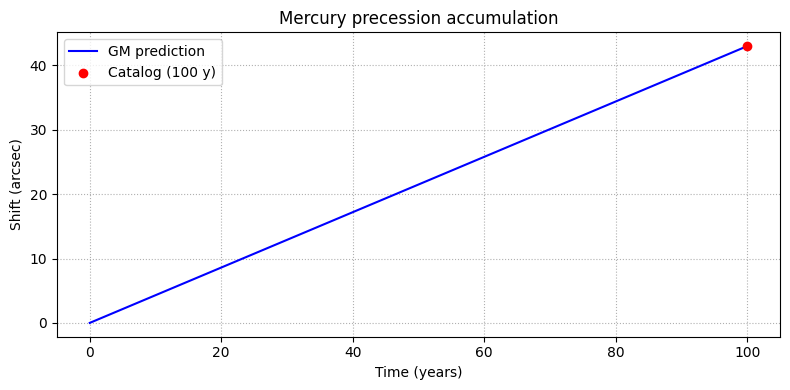

In [3]:
# TEST I: MERCURY PERIHELION
# ==========================

# Semilatus rectum
p_mer = a_mer_m * (1.0 - e_mer**2)

# GM shift per orbit (radians)
shift_rad = (6.0 * math.pi * mu_m) / p_mer

# Arcsec per century
arcsec_cy = shift_rad * ARCSEC * (century_s / T_mer_s)
obs_cy = 42.98  # catalog residual (arcsec/century)
rel_err_peri = 100.0 * (arcsec_cy - obs_cy) / obs_cy

print("[Test I] Orbital Precession (Sun–Mercury)")
print(f"  GM prediction     : {arcsec_cy:.4f} arcsec/cy")
print(f"  Catalog reference : {obs_cy:.4f} arcsec/cy")
print(f"  Rel. error        : {rel_err_peri:.3e} %")

# Visualisation: accumulation over 100 years
years = np.linspace(0.0, 100.0, 200)
y_gm = (arcsec_cy / 100.0) * years

plt.figure(figsize=(8, 4))
plt.plot(years, y_gm, label="GM prediction", color='b')
plt.scatter([100], [obs_cy], color='r', label="Catalog (100 y)", zorder=5)
plt.title("Mercury precession accumulation")
plt.xlabel("Time (years)")
plt.ylabel("Shift (arcsec)")
plt.legend(); plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()


### Corollary II — Light Deflection (Amplitude)

**Setup.** 
Ray-like probe (eikonal limit) with impact parameter $b$ in the index
profile of a central source, in the same small-gradient regime.

**GM consequence (geometric profile).** 
In the linearised GM eikonal limit, the index profile
$$n(r) = 1 + \frac{2\mu}{r}$$
yields a deflection angle
$$\delta_{\rm GM}(b) = \frac{4\mu}{b}.$$
At the Solar limb ($b = R_\odot$), this gives the prediction for Test II.

**Baseline comparison.** 
A Newtonian corpuscular treatment with the same length scale can be summarised,
to leading order, as a deflection
$$\delta_{\rm baseline}(b) = \frac{2\mu}{b},$$
which is included only as a reference curve.

**Falsification (amplitude).** 
If the limb deflection measured at $b = R_\odot$ deviates from
$\delta_{\rm GM}(R_\odot) = 4\mu/R_\odot$ by more than the observational
uncertainty, this corollary is challenged in the Solar window.

#### Corollary IIb — Entropic Shape Test ($1/b^2$ vs $1/b$)

**Setup.** 
GM allows matter/noise corrections to the effective index, modelling capacity
limits in the channel. An entropic variant with a $1/r^2$ correction yields a
deflection of the form
$$\delta_{\rm ent}(b) = \frac{4\mu R_\odot}{b^2},$$
chosen such that $\delta_{\rm ent}(R_\odot) = \delta_{\rm GM}(R_\odot)$.

**Shape comparison.** 
Both GM variants agree at the limb by construction, but differ away from it:
$$\delta_{\rm GM}(b) = \frac{4\mu}{b}, \qquad
  \delta_{\rm ent}(b) = \frac{4\mu R_\odot}{b^2}.$$
The residual
$$\Delta\delta(b) = \delta_{\rm ent}(b) - \delta_{\rm GM}(b)$$
is a GM prediction for off-limb deflection shape.




[Test II] Light deflection at Solar limb
  GM prediction     : 1.7512 arcsec
  Catalog reference : 1.7500 arcsec
  Rel. error        : 7.104e-02 %
  Baseline (2 mu/b) : 0.8756 arcsec (reference)


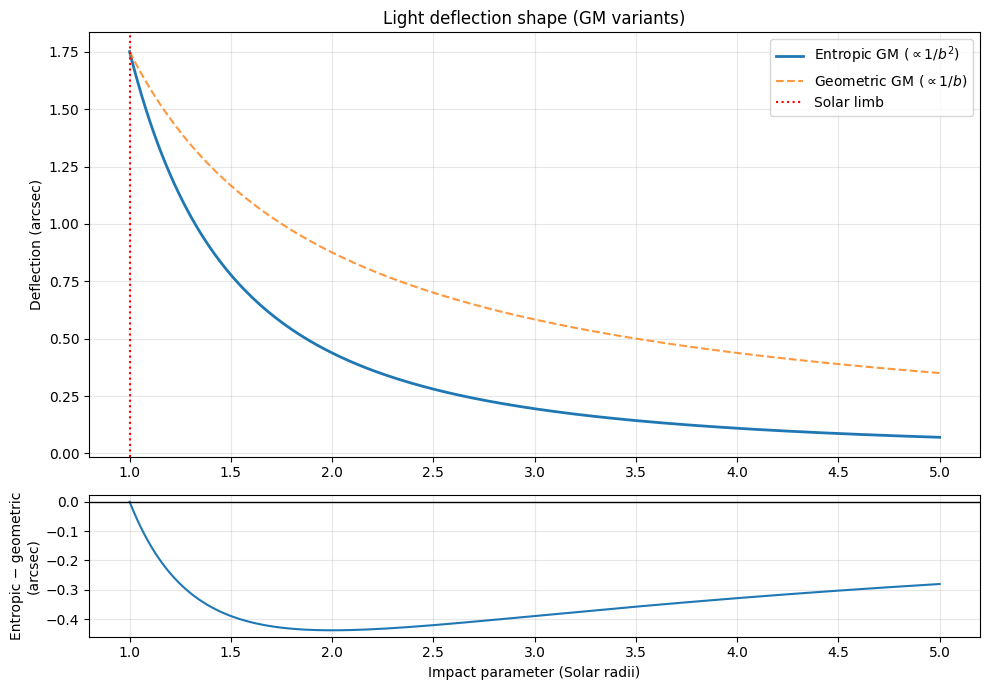

In [4]:
# TEST II & IIb: LIGHT DEFLECTION (LIMB + SHAPE)
# ==============================================

b_limb = R_sun_m
defl_rad_gm = (4.0 * mu_m) / b_limb
defl_arcsec_gm = defl_rad_gm * ARCSEC
defl_arcsec_baseline = (2.0 * mu_m / b_limb) * ARCSEC
obs_lens = 1.75

rel_err_limb = 100.0 * (defl_arcsec_gm - obs_lens) / obs_lens

print("\n[Test II] Light deflection at Solar limb")
print(f"  GM prediction     : {defl_arcsec_gm:.4f} arcsec")
print(f"  Catalog reference : {obs_lens:.4f} arcsec")
print(f"  Rel. error        : {rel_err_limb:.3e} %")
print(f"  Baseline (2 mu/b) : {defl_arcsec_baseline:.4f} arcsec (reference)")

b_vals_shape = np.linspace(1.0, 5.0, 200)  # in Solar radii
b_m_shape = b_vals_shape * R_sun_m
defl_geom = (4.0 * mu_m / b_m_shape) * ARCSEC
defl_ent = (4.0 * mu_m * R_sun_m / (b_m_shape**2)) * ARCSEC
residual_shape = defl_ent - defl_geom

fig = plt.figure(figsize=(10, 7))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])

ax0 = plt.subplot(gs[0])
ax0.plot(b_vals_shape, defl_ent, label=r"Entropic GM ($\propto 1/b^2$)", linewidth=2.0)
ax0.plot(b_vals_shape, defl_geom, "--", label=r"Geometric GM ($\propto 1/b$)", alpha=0.8)
ax0.axvline(1.0, color='r', linestyle=':', label='Solar limb')
ax0.set_ylabel("Deflection (arcsec)")
ax0.set_title("Light deflection shape (GM variants)")
ax0.legend(loc="upper right")
ax0.grid(True, alpha=0.3)

ax1 = plt.subplot(gs[1], sharex=ax0)
ax1.plot(b_vals_shape, residual_shape)
ax1.axhline(0.0, color="k", linewidth=1.0)
ax1.set_xlabel("Impact parameter (Solar radii)")
ax1.set_ylabel("Entropic − geometric\n(arcsec)")
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Corollary III — GM Time-Closure Redshift

**Setup.** 
Two GM frames: emitter at radius $R$ in the source gradient and observer at an
effectively asymptotic radius. The GM time factor is set by the same structure
that governs refraction.

**GM consequence.** 
In the small-gradient regime, the time factor can be written as
$$\gamma(R) = 1 + \frac{\mu}{R} + \mathcal{O}(\epsilon^2),$$
with $\epsilon(R) = |\mu|/R \ll 1$. For a signal emitted with proper
frequency $\nu_{\rm em}$ at $R$ and observed with $\nu_{\rm obs}$ at
asymptotic radius, the leading-order fractional shift is
$$z(R) \equiv \frac{\nu_{\rm em} - \nu_{\rm obs}}{\nu_{\rm obs}} \simeq \frac{\mu}{R}.$$

**Specialisation (Solar surface).** 
At $R = R_\odot$ this gives
$$z_\odot \simeq \frac{\mu}{R_\odot},$$
which is numerically evaluated using the SI-2019 temporal-form value of $\mu$ and
compared to the catalog Solar surface redshift.

**Falsification.** 
If $|z_{\rm GM} - z_{\rm obs}|$ exceeds the observational uncertainty in this
small-gradient Solar window, the GM time-closure model is challenged.




[Test III] Solar surface redshift
  GM prediction  : 2.122567e-06
  Catalog value  : 2.120000e-06
  Abs. error     : 2.567e-09
  Rel. error     : 1.211e-01 %


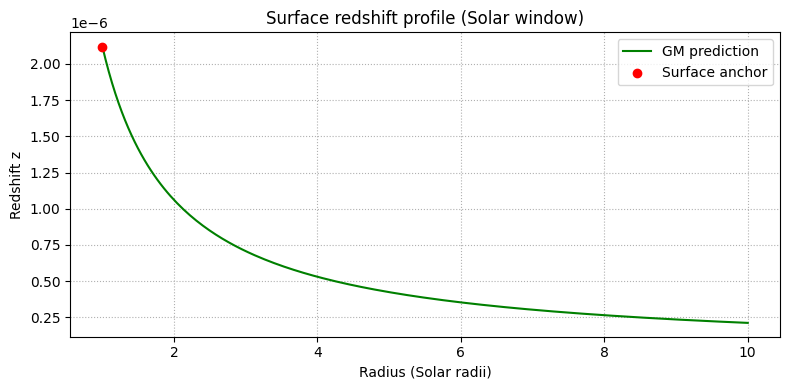

In [5]:
# TEST III: SOLAR SURFACE REDSHIFT
# =================================

z_surf = mu_m / R_sun_m
obs_z = 2.12e-6
rel_err_z = 100.0 * (z_surf - obs_z) / obs_z

print("\n[Test III] Solar surface redshift")
print(f"  GM prediction  : {z_surf:.6e}")
print(f"  Catalog value  : {obs_z:.6e}")
print(f"  Abs. error     : {z_surf - obs_z:.3e}")
print(f"  Rel. error     : {rel_err_z:.3e} %")

r_vals = np.linspace(R_sun_m, 10.0 * R_sun_m, 200)
z_curve = mu_m / r_vals

plt.figure(figsize=(8, 4))
plt.plot(r_vals / R_sun_m, z_curve, label="GM prediction", color='g')
plt.scatter([1.0], [obs_z], color='r', label="Surface anchor", zorder=5)
plt.title("Surface redshift profile (Solar window)")
plt.xlabel("Radius (Solar radii)")
plt.ylabel("Redshift z")
plt.legend(); plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()


In [6]:
# MACRO SUMMARY TABLE (TESTS I–III)
# =================================

macro_tests = [
    "Mercury perihelion (arcsec/cy)",
    "Solar limb deflection (arcsec)",
    "Solar redshift z"
]

gm_pred = [arcsec_cy, defl_arcsec_gm, z_surf]
catalog = [obs_cy, obs_lens, obs_z]
abs_err = [arcsec_cy - obs_cy, defl_arcsec_gm - obs_lens, z_surf - obs_z]
rel_err = [rel_err_peri, rel_err_limb, rel_err_z]

df_macro = pd.DataFrame({
    "Test": macro_tests,
    "GM prediction": gm_pred,
    "Catalog value": catalog,
    "Abs. error": abs_err,
    "Rel. error (%)": rel_err,
})

pd.set_option('display.float_format', '{:.6e}'.format)
print("\nMacro Solar tests (GM vs catalog):")
display(df_macro)



Macro Solar tests (GM vs catalog):


,Test,GM prediction,Catalog value,Abs. error,Rel. error (%)
0,Mercury perihelion (arcsec/cy),4.298198e+01,4.298000e+01,1.975497e-03,4.596318e-03
1,Solar limb deflection (arcsec),1.751243e+00,1.750000e+00,1.243281e-03,7.104465e-02
2,Solar redshift z,2.122567e-06,2.120000e-06,2.566754e-09,1.210733e-01


### Note: Small-Gradient Structure in the Solar Window

In the Solar tests above, the linearised GM comparison formulas
$$\Delta\phi_{\rm GM} = \frac{6\pi\mu}{p}, \qquad
  \delta_{\rm GM}(b) = \frac{4\mu}{b}, \qquad
  z_{\rm GM}(R) = \frac{\mu}{R}$$
were evaluated using the numerical value of $\mu$ obtained from the SI-2019 temporal rewrite. With that numerical assignment, the GM predictions coincide with the standard Solar benchmarks used in the notebook.

In this window, the main point is that these formulas are the **first-order terms** of a nonlinear GM refraction and frame-closure structure in the small-gradient regime. The agreement comes from the shared leading-order expansion in $\mu/r$.

GM extends beyond this regime in two directions visible in this notebook:

1. **Matter / vacuum noise corrections** introduce alternative index profiles (for example $1/b^2$) that change the off-limb deflection shape.
2. **Bandwidth and rate-limit effects** produce discrete hydrogen shell radii via time–information complementarity and action counting in the temporal convention.


## 3. Micro-Scale Extensions (Hydrogen)

**Context.**  
At atomic scales ($\sim 10^{-10}$ m), the GM channel capacity saturates and only discrete stable motifs are compatible with the time–information bound. Here we test:

1. The electron rest-energy rate from the SI-2019 mass-to-rate rewrite.  
2. Hydrogen shell radii from GM time–information + least action, compared to the Bohr scaling $r_n = n^2 a_0$.

### Corollary IV — Electron Rest-Energy Rate (SI-2019 Check)

**Setup.**  
In the SI-2019 temporal form used here, transport speeds are normalised by $c$ through the ratio $v/c$, while energy-like quantities are read as rates through division by $h$. A catalog mass $m$ in kilograms is therefore rewritten as
$$f_{\rm Kz}(m) \equiv f_{\rm Hz}(m) \equiv m_{\rm Kz}(m) = \frac{m c^2}{h}.$$
The resulting quantity is reported numerically in **Hz** and is the rate used in the hydrogen-shell calculation below.

**Purpose.**  
Test IV reports the electron rate used in the hydrogen-shell calculation below, ensuring a traceable bridge between the catalog mass in kg and the SI-2019 temporal-rate form used by the notebook.

In [7]:
# TEST IV: ELECTRON REST-ENERGY RATE
# ==================================
print("\n[Test IV] Electron rest-energy rate")
print(f"  f_e = {f_elec_hz:.4e} Hz")



[Test IV] Electron rest-energy rate
  f_e = 1.2356e+20 Hz


### Corollary V — Hydrogen Shell Radii (GM Time–Information Limit)

**Setup.**  
Single-electron hydrogen motif in a bandwidth-limited confinement regime. The GM time–information bound constrains the update rate, and GM least-action closure requires an integer action count on closed loops.

**GM consequence.**  
In temporal-rate variables, these constraints yield shell radii of the form
$$r_n = \frac{n^2 c}{2\pi f_e \alpha},$$
where $f_e$ is the electron rest-energy rate [Hz] and $\alpha$ is the coupling strength (fine structure constant). The factor $2\pi$ corresponds to the circumference of the closed loop and is distinct from spherical flux factors.

Using the SI-2019 mass-to-rate rewrite for $f_e$ and the SI value of $\alpha$, the numerical values of $r_n$ computed below coincide with the reference Bohr radii $n^2 a_0$ to high precision. This reproduces the familiar shell structure from GM time–information plus action, without importing the Schrödinger equation as a premise.

**Falsification.**  
If the residuals $|r_n^{\rm GM} - n^2 a_0|$ across several $n$ exceed a tolerance set by experimental precision, the GM construction is falsified in this hydrogen window.


In [8]:
# TEST V: HYDROGEN SHELL RADII (GM vs Bohr)
# =========================================

def calc_hydrogen_radius(n, f_e=f_elec_hz, alpha=alpha_fs):
    """GM radius in the temporal convention: r_n = (n^2 * c) / (2*pi * f_e * alpha)."""
    return (n**2 * c_SI) / (2.0 * math.pi * f_e * alpha)

n_levels = np.array([1, 2, 3, 4])
radii_gm = np.array([calc_hydrogen_radius(n) for n in n_levels])
radii_ref = a0_ref * n_levels**2
residuals = radii_gm - radii_ref
rel_err = 100.0 * residuals / radii_ref

df_h = pd.DataFrame({
    "n": n_levels,
    "GM radius r_n (m)": radii_gm,
    "Ref radius n^2 a0 (m)": radii_ref,
    "Abs. error (m)": residuals,
    "Rel. error (%)": rel_err,
})

pd.set_option('display.float_format', '{:.6e}'.format)
print("\n[Test V] Hydrogen shells (GM vs Bohr)")
display(df_h)



[Test V] Hydrogen shells (GM vs Bohr)


,n,GM radius r_n (m),Ref radius n^2 a0 (m),Abs. error (m),Rel. error (%)
0,1,5.291772e-11,5.291772e-11,8.246186e-19,1.558303e-06
1,2,2.116709e-10,2.116709e-10,3.298474e-18,1.558303e-06
2,3,4.762595e-10,4.762595e-10,7.421568e-18,1.558303e-06
3,4,8.466836e-10,8.466835e-10,1.319390e-17,1.558303e-06


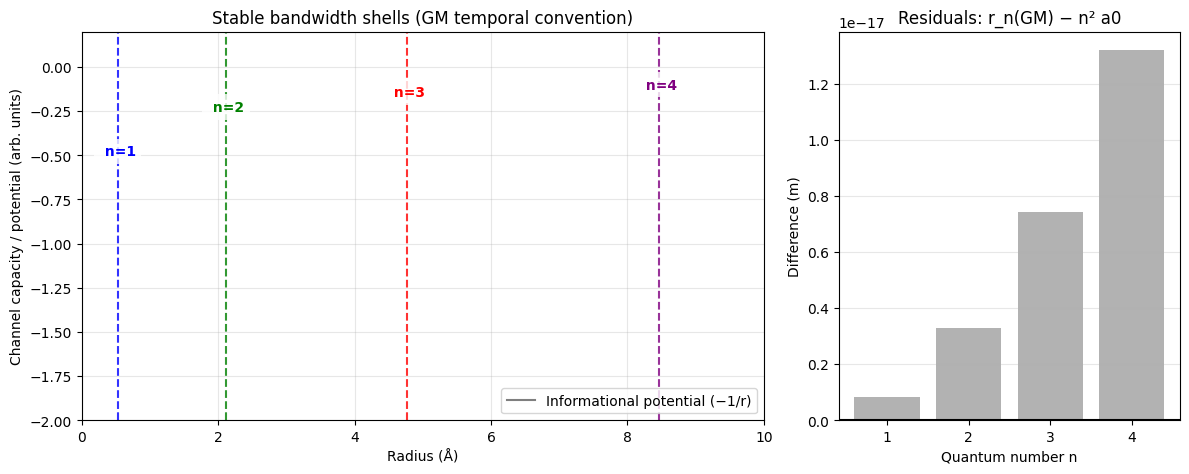

In [9]:
# VISUALISATION: HYDROGEN POTENTIAL + RESIDUALS
# ============================================

fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1])

# Graph A: Informational potential & shells
ax0 = plt.subplot(gs[0])
r_space = np.linspace(0.1e-10, 10e-10, 500)
potential = -1.0 / r_space  # arbitrary units

ax0.plot(r_space * 1e10, potential, 'k-', alpha=0.5,
         label='Informational potential (−1/r)')
colors = ['blue', 'green', 'red', 'purple']

for n, r, col in zip(n_levels, radii_gm, colors):
    ax0.axvline(r * 1e10, color=col, linestyle='--', alpha=0.8)
    ax0.text(r * 1e10, -0.5 / n,
             f' n={n}',
             color=col,
             ha='center',
             fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

ax0.set_title("Stable bandwidth shells (GM temporal convention)")
ax0.set_xlabel("Radius (Å)")
ax0.set_ylabel("Channel capacity / potential (arb. units)")
ax0.set_xlim(0.0, 10.0)
ax0.set_ylim(-2.0, 0.2)
ax0.grid(True, alpha=0.3)
ax0.legend(loc='lower right')

# Graph B: residuals
ax1 = plt.subplot(gs[1])
ax1.bar(n_levels, residuals, color='gray', alpha=0.6)
ax1.axhline(0.0, color='k')
ax1.set_title("Residuals: r_n(GM) − n² a0")
ax1.set_xlabel("Quantum number n")
ax1.set_ylabel("Difference (m)")
ax1.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Macro-Scale Extensions (Galactic)

**Context.** At galactic scales ($r \gg R_{\text{core}}$), a purely Keplerian falloff does not reproduce the familiar flat outer-rotation pattern. This section presents a public comparison window written in **SI-2019 temporal form**: a Keplerian baseline, a GR-style SI-temporal correction, and GM 2D confinement scaling.

The bookkeeping background follows the AFC reading: finite distinctions with discrete / ternary counting. The plotted radial curves are the continuous numerical comparison layer used for the public figure.

### Galactic Rotation Comparison

In the comparison used here, the metre and kilogram reporting layers are handled through their time-based defining relations. Differentiating the physical radius as a product $r(t)u_m(t)$ gives
$$\frac{d^2}{dt^2}[r(t) u_m(t)] = \ddot{r}u_m + 2\dot{r}\dot{u}_m + r\ddot{u}_m.$$
The last term is the extra unit-derivative contribution retained in the GR-style comparison curve. The comparison is included to expose the chain-rule term that disappears when the temporal dependence of the reporting unit is left implicit.

On the GM side, the galactic disc is treated as a 2D confinement window. With boundary scaling $A_2(r) \propto r$, the frame amplitude scales as $|E_I| \propto 1/r$, which is the scaling used for the flat outer-rotation comparison below.

The figure therefore compares three curves:

1. a Keplerian baseline,
2. a GR-style SI-temporal curve retaining the $r\ddot{u}_m$ residue,
3. a GM 2D confinement curve.

The flat reference points are included as the outer-disc comparison reference used in the figure.



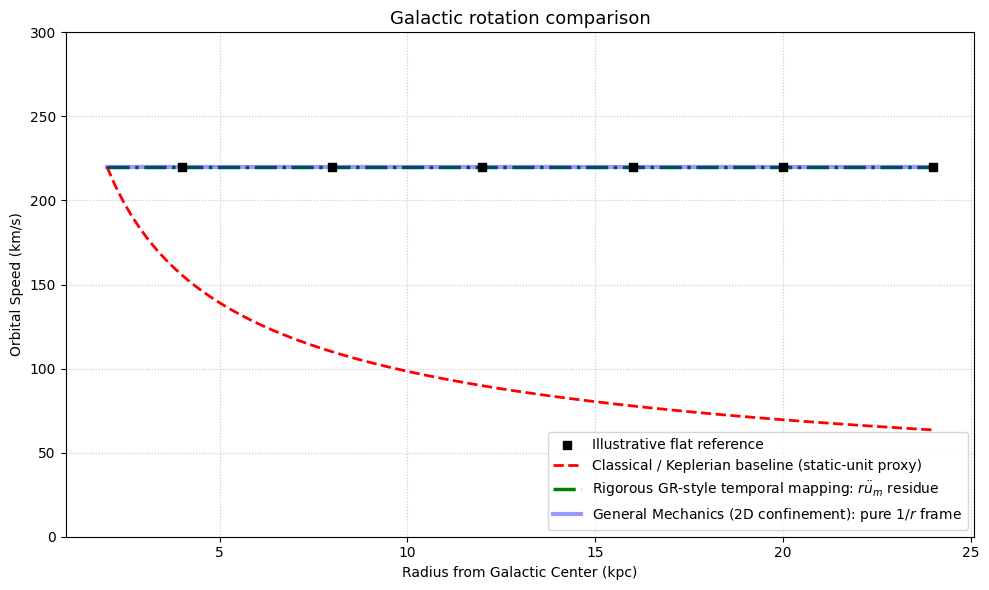


[Test VI] Galactic Rotation (r >> R_core)
  Flat reference            : 220.0 km/s
  Classical at 24 kpc        : 63.5 km/s (Falls below flat target)
  Rigorous GR-style at 24 kpc: 220.0 km/s
  GM 2D confinement at 24 kpc: 220.0 km/s


In [10]:
# TEST VI: GALACTIC ROTATION (GM UPDATE + GR COMPARISON)
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# -- 1. Temporal Inputs in SI-2019 form --
# We use c_SI from the previously initialized SI-2019 temporal environment
v_catalog_km_s = 220.0
v_target_dim = (v_catalog_km_s * 1000.0) / c_SI

# Define Galactic Bulge (3D) to Disc (2D) boundary (~2.0 kpc for Milky Way)
R_core_kpc = 2.0
radii_kpc = np.linspace(2.0, 24.0, 100)

# -- 2. Model A: Classical / Keplerian baseline --
# Static-unit proxy: drops as 1/sqrt(r), missing the flat target.
v_classical_dim = v_target_dim * np.sqrt(R_core_kpc / radii_kpc)
v_classical_km_s = (v_classical_dim * c_SI) / 1000.0

# -- 3. Model B: GR-style SI-temporal comparison --
# Keeps the r*ddot{u}_m geometric unit-derivative term.
# ddot{u}_m scales as 1/r^2, integrating to a constant v^2 residue.
v_geom_dim_sq = v_target_dim**2
v_fixed_dim = np.sqrt(v_classical_dim**2 + v_geom_dim_sq * (1.0 - R_core_kpc / radii_kpc))
v_fixed_km_s = (v_fixed_dim * c_SI) / 1000.0

# -- 4. Model C: General Mechanics (2D confinement flow) --
# Pure 2D disc boundary area A_2(r) ~ r, leading to E_I ~ 1/r.
v_gm_dim = np.full_like(radii_kpc, v_target_dim)
v_gm_km_s = (v_gm_dim * c_SI) / 1000.0

# -- 5. Visualisation --
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

# Flat reference points
ax.scatter(
    [4, 8, 12, 16, 20, 24],
    np.full(6, v_catalog_km_s),
    color='k',
    marker='s',
    s=40,
    zorder=5,
    label='Illustrative flat reference',
)

# Plot Models
ax.plot(
    radii_kpc,
    v_classical_km_s,
    'r--',
    linewidth=2,
    label='Classical / Keplerian baseline (static-unit proxy)',
)
ax.plot(
    radii_kpc,
    v_fixed_km_s,
    'g-.',
    linewidth=2.5,
    label='Rigorous GR-style temporal mapping: $r\\ddot{u}_m$ residue',
)
ax.plot(
    radii_kpc,
    v_gm_km_s,
    'b-',
    linewidth=3,
    alpha=0.4,
    label='General Mechanics (2D confinement): pure $1/r$ frame',
)

ax.set_title("Galactic rotation comparison", fontsize=13)
ax.set_xlabel("Radius from Galactic Center (kpc)")
ax.set_ylabel("Orbital Speed (km/s)")
ax.set_ylim(0, 300)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# Print text outputs matching prior tests
print("\n[Test VI] Galactic Rotation (r >> R_core)")
print(f"  Flat reference            : {v_catalog_km_s:.1f} km/s")
print(f"  Classical at 24 kpc        : {v_classical_km_s[-1]:.1f} km/s (Falls below flat target)")
print(f"  Rigorous GR-style at 24 kpc: {v_fixed_km_s[-1]:.1f} km/s")
print(f"  GM 2D confinement at 24 kpc: {v_gm_km_s[-1]:.1f} km/s")


## 5. References

**General Mechanics**  
> Reginald, P. (2025). *General Mechanics*. Zenodo. https://doi.org/10.5281/zenodo.17561404

**AFC / discrete Stokes bookkeeping**  
> Reginald, P. (2025). *Axiomatic Fundamentalism Calculus (AFC): The Hidden Form of Stokes*. Zenodo. https://doi.org/10.5281/zenodo.17807779

**SI-2019 temporal definitions and rate conversion**  
> BIPM. *The International System of Units (SI): defining constants*. https://www.bipm.org/en/measurement-units/si-defining-constants

> BIPM. *SI base unit: kilogram (kg).* https://www.bipm.org/en/si-base-units/kilogram

> BIPM. *Mise en pratique – metre*. https://www.bipm.org/documents/20126/41489670/SI-App2-metre.pdf

> NIST. *Unit Conversion: kg to Hz*. https://physics.nist.gov/cgi-bin/cuu/Convert?exp=0&num=1&From=kg&To=hz&Action=Convert+value+and+show+factor

